In [24]:
from pathlib import Path
import seaborn as sns
import os
from itertools import islice
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm

# needed when use_determinist_algoriithms is used in CUDA > 10.2, before importing pytorch
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as v2
from torchvision.models import resnet18
from torch.optim import SGD, Adam

plt.rcParams["savefig.bbox"] = 'tight'

def seed():
  SEED = 123456789
  random.seed(SEED)
  np.random.seed(SEED)
  torch.manual_seed(SEED)
  torch.cuda.manual_seed(SEED)
  torch.cuda.manual_seed_all(SEED)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False
  torch.use_deterministic_algorithms(True)

def seed_worker(worker_id):
  worker_seed = torch.initial_seed() % 2**32
  np.random.seed(worker_seed)
  random.seed(worker_seed)

BLUEBERRY_ROOT = Path.home() / "BLUEBERRY_DATA"
CLASSIFICATION_ROOT =  BLUEBERRY_ROOT / "CLASSIFICATION"

TRAIN_DIR = CLASSIFICATION_ROOT / "train"
DEV_DIR = CLASSIFICATION_ROOT / "dev"

In [25]:
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Device: {DEVICE}")

lr = 1e-3
BATCH_SIZE = 256
EPOCHS = 20

Device: cuda


In [26]:
# NOTE: if I add random transforms then I need seed_worker for determinism in dataloading
transforms = v2.Compose([
  v2.Resize((64, 64)),
  v2.ToImage(),
  # v2.CenterCrop(),

  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=[0.4292, 0.5389, 0.3654], std=[0.1860, 0.2121, 0.1966])
  # [0.4291510581970215, 0.5389042496681213, 0.3654465973377228], [0.18595948815345764, 0.21214619278907776, 0.19659456610679626]
])

class ZeroDataset(Dataset):
  def __init__(self, base_dataset):
    self.base_dataset = base_dataset

  def __len__(self):
    return len(self.base_dataset)

  def __getitem__(self, idx):
    _, y = self.base_dataset[idx]

    # x = torch.zeros(3, 64, 64)
    x = torch.randn(3, 64, 64) # random noise
    return x, y

g = torch.Generator().manual_seed(0)
train_dataset = ImageFolder(TRAIN_DIR, transform=transforms)
dev_dataset = ImageFolder(DEV_DIR, transform=transforms)
# zero_dataset = ZeroDataset(dataset) # to verify it doesn't learn on zero input

# ================================================================
class_counts = np.bincount(train_dataset.targets)
weights = 1 / (class_counts + 1e-6)
# weights / weights.sum() # BETTER ?
weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

sample_weights = [weights[t] for t in train_dataset.targets]
sampler = WeightedRandomSampler( sample_weights, num_samples=len(sample_weights), replacement=True)
# ================================================================

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=12, generator=g)
# train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=12, generator=g)
dev_dataloader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=12, generator=g)
# dataloader = DataLoader(zero_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=12, generator=g)
# dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, worker_init_fn=seed_worker, generator=g)

NUM_CLASSES = len(train_dataset.classes)
# ** TODO: MAKE SURE THIS DOES WHAT I THINK! e.g. that the order is correct, 0:bud, 1:flower, ...
CLASS_NAMES = ["bud", "flower", "green", "pink", "purple", "blue"]

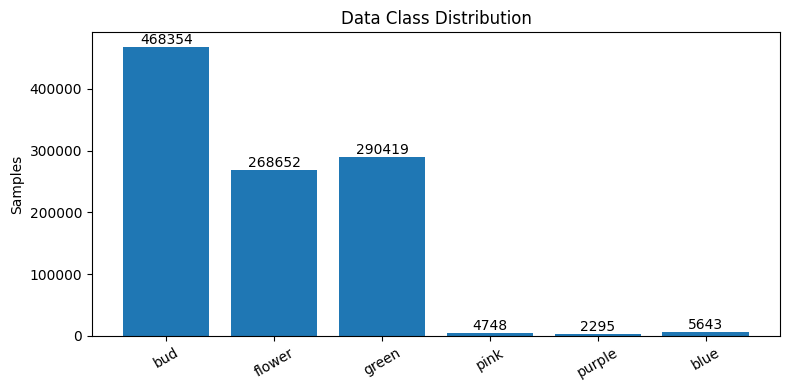

In [27]:
targets = np.array(train_dataset.targets)
class_counts = np.bincount(targets)

plt.figure(figsize=(8, 4))
bars = plt.bar(CLASS_NAMES, class_counts)

# add counts above bars
for bar, count in zip(bars, class_counts):
  plt.text( bar.get_x() + bar.get_width()/2, bar.get_height(), str(count), ha='center', va='bottom')

plt.ylabel("Samples")
plt.title("Data Class Distribution")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [28]:
# # Calculate Train data mean and std for normalization
# loader = DataLoader(train_dataset, batch_size=256, shuffle=False, num_workers=12, generator=g)

# channels_sum = 0
# channels_squared_sum = 0
# num_pixels = 0

# # for images, _ in islice(loader, 1):
# for images, _ in tqdm(loader):
#   channels_sum += torch.sum(images, dim=[0, 2, 3])
#   channels_squared_sum += torch.sum(images ** 2, dim=[0, 2, 3])

#   num_pixels += ( images.shape[0] * images.shape[2] * images.shape[3])

# mean = channels_sum / num_pixels
# std = (channels_squared_sum / num_pixels - mean ** 2) ** 0.5

# print(f"Mean: {mean} | std: {std}")

In [29]:
# quick and dirty
# def compute_confusion_matrix(model, loader, num_classes):
#     model.eval()
    
#     all_preds = []
#     all_labels = []

#     with torch.no_grad():
#         for images, labels in loader:
#             images = images.to(DEVICE)
#             outputs = model(images)

#             _, preds = torch.max(outputs, 1)

#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(labels.numpy())

#     cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
#     return cm

def plot_confusion_matrix(cm, class_names):
  '''
  TODO: plot percentages ?
  '''
  plt.figure(figsize=(6,4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
              xticklabels=class_names,
              yticklabels=class_names)
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title("Confusion Matrix")
  plt.show()

def plot_prediction_dynamics(images:torch.Tensor, labels:torch.Tensor, preds:torch.Tensor):
  '''
  use one small constant batch (21) of test images to display predictions on during training. 
  For sanity check..
  '''
  fig, axes = plt.subplots(3, 7, figsize=(10, 4))

  for i, ax in enumerate(axes.flat):
    img = images[i]
    img = (img - img.min()) / (img.max() - img.min()) # if it is normalized, this avoids range warning
    # CHW -> HWC
    img = img.permute(1,2,0)

    ax.imshow(img)

    label = labels[i].item()
    pred = preds[i].item()
    ax.set_title(f"{CLASS_NAMES[pred]}({CLASS_NAMES[label]})")
    ax.axis("off")

  plt.tight_layout()
  plt.show()

In [31]:
# class_counts = np.bincount(train_dataset.targets)
# weights = 1 / (class_counts + 1e-6)
# # weights / weights.sum() # BETTER ?
# weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

In [32]:
seed()
model = resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(DEVICE)

loss_fn = nn.CrossEntropyLoss()
# loss_fn = nn.CrossEntropyLoss(weight=weights)
optimizer = Adam(model.parameters(), lr=lr)

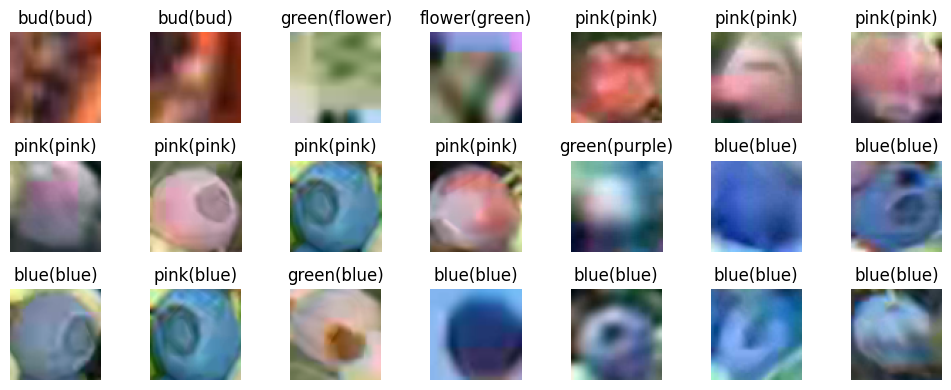

Epoch 0 loss : 0.276140 | acc: 89.73 %
dev_loss : 0.829979 | dev_acc: 78.26 %


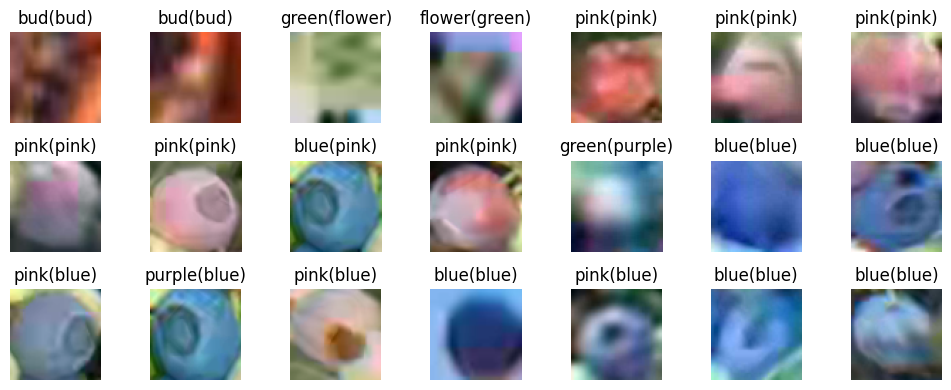

Epoch 1 loss : 0.157333 | acc: 94.24 %
dev_loss : 2.151758 | dev_acc: 60.87 %


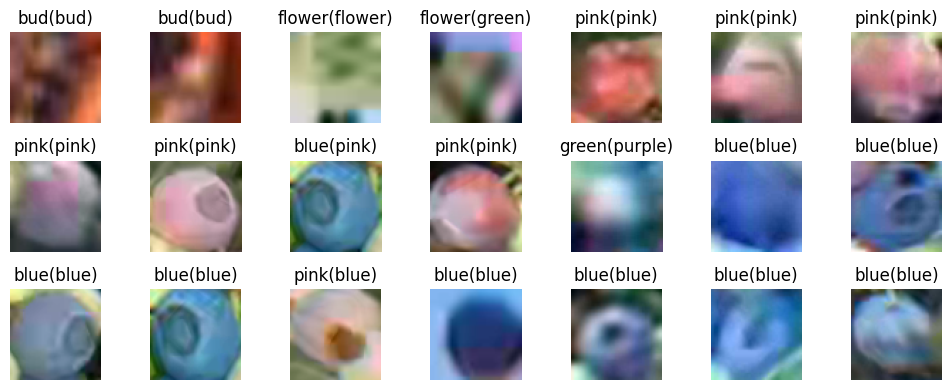

Epoch 2 loss : 0.140235 | acc: 94.84 %
dev_loss : 1.920104 | dev_acc: 78.26 %


KeyboardInterrupt: 

In [33]:
lossi = []
acci = []
dev_lossi = []
dev_acci = []
for epoch in range(EPOCHS):
  model.train()

  train_loss = 0
  correct = 0
  all_preds: list[int] = [] # to construct confusion matrix
  all_y = []

  # for i, (Xb, Yb) in islice(enumerate(dataloader), 1):
  for i, (Xb, Yb) in enumerate(train_dataloader):
    Xb, Yb = Xb.to(DEVICE), Yb.to(DEVICE)

    optimizer.zero_grad(set_to_none=True)
    out = model(Xb) # 128xNUM_CLASSES
    loss = loss_fn(out, Yb)
    loss.backward()
    optimizer.step()

    train_loss += loss.detach().item()
    _, pred = torch.max(out, 1)
    correct += pred.eq(Yb).float().sum().item()

    # all_preds.extend(pred.cpu().numpy())
    # all_y.extend(Yb.cpu().numpy())

  lossi.append(train_loss / len(train_dataloader))
  acci.append(100 * correct / len(train_dataloader.dataset))

  # validate
  model.eval()
  dev_loss = 0
  dev_correct = 0
  with torch.no_grad():
    for i, (Xb, Yb) in enumerate(dev_dataloader):
      Xb, Yb = Xb.to(DEVICE), Yb.to(DEVICE)

      out = model(Xb)
      loss = loss_fn(out, Yb)
      dev_loss += loss.detach().item()
      _, pred = torch.max(out, 1)
      dev_correct += pred.eq(Yb).float().sum().item()
    
    # when I create the splits, use a predefined set of images here, not each batch
    plot_prediction_dynamics(Xb.cpu(), Yb.cpu(), pred.cpu())

  dev_loss /= len(dev_dataloader)
  dev_lossi.append(dev_loss)
  dev_acci.append(100*dev_correct / len(dev_dataloader.dataset))

  # cm = confusion_matrix(all_y, all_preds, labels=list(range(NUM_CLASSES)))
  # plot_confusion_matrix(cm, CLASS_NAMES)
  print(f"Epoch {epoch} loss : {train_loss / len(train_dataloader):.6f} | acc: {100 * correct / len(train_dataloader.dataset):.2f} %")
  print(f"dev_loss : {dev_loss / len(dev_dataloader):.6f} | dev_acc: {100 * dev_correct / len(dev_dataloader.dataset):.2f} %")
  print("==========================================================================")

In [ ]:
class FocalLoss(nn.Module):

    def __init__(
        self,
        alpha=None,
        gamma=2.0,
        reduction='mean'
    ):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):

        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction='none',
            weight=self.alpha
        )

        pt = torch.exp(-ce_loss)

        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()

        elif self.reduction == 'sum':
            return focal_loss.sum()

        return focal_loss

criterion = FocalLoss( gamma=2.0)
class_weights = torch.tensor([
    1.0,
    2.5,
    3.0,
    1.2,
    4.0,
    5.0
]).to(device)

criterion = FocalLoss( alpha=class_weights, gamma=2.0)

In [ ]:
Epoch 0 loss : 0.332118 | acc: 87.68 %
Epoch 1 loss : 0.273915 | acc: 89.83 %


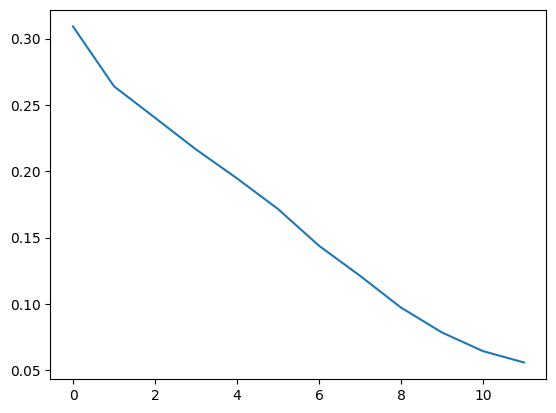

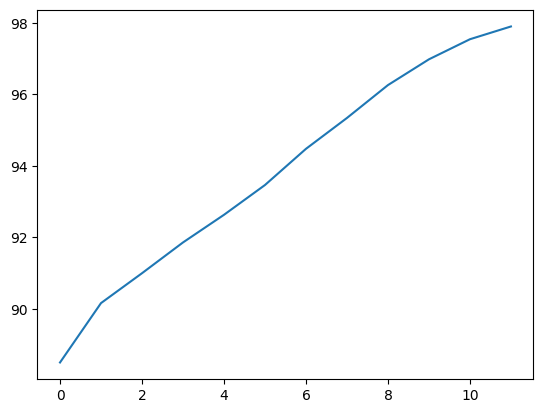

In [17]:
plt.plot(lossi);
plt.show()
plt.plot(acci);

loss: 2.254592 | acc: 10.94 % [    0 / 1040134 ]
loss: 0.444183 | acc: 83.59 % [128000 / 1040134 ]
loss: 0.336097 | acc: 88.28 % [256000 / 1040134 ]
loss: 0.407102 | acc: 88.28 % [384000 / 1040134 ]
loss: 0.378203 | acc: 88.28 % [512000 / 1040134 ]
loss: 0.324641 | acc: 87.50 % [640000 / 1040134 ]
loss: 0.380563 | acc: 86.72 % [768000 / 1040134 ]
loss: 0.372520 | acc: 82.03 % [896000 / 1040134 ]
loss: 0.295014 | acc: 90.62 % [1024000 / 1040134 ]


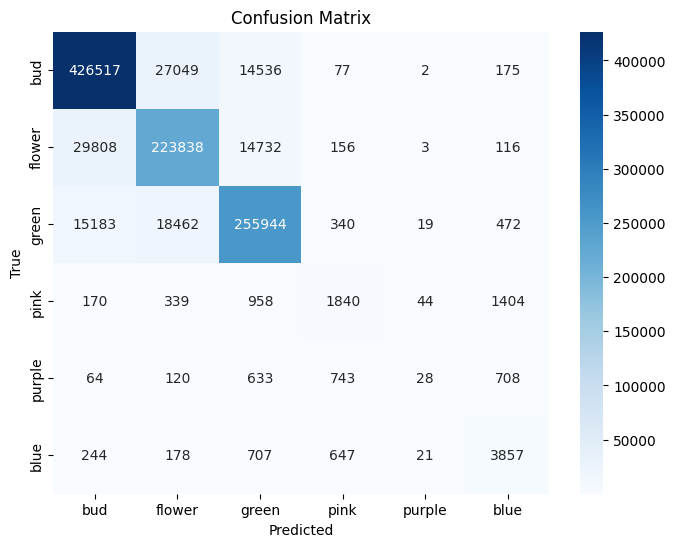

Epoch 0 Loss = 0.332118 | Accuracy = 87.680853 %


In [ ]:
lossi = []
acci = []
for epoch in range(EPOCHS):
  model.train()
  # print(f"Epoch {t+1}\n-------------------------------")
  # train(dataloader, model, loss_fn, optimizer)
  # test(test_dataloader, model, loss_fn)
  # print(f"Epoch {epoch}\n=========================")

  running_loss = 0.0
  running_acc = 0.0

  all_preds = []
  all_labels = []

  for batch_idx , (Xb, yb) in enumerate(dataloader):
    Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)

    # Compute prediction error
    out = model(Xb)  # (batch_size, num_classses)
    loss = loss_fn(out, yb)

    # Backpropagation
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    _, pred = torch.max(out, 1)
    correct = (pred == yb).sum().item()
    acc = correct / yb.size(0)

    all_preds.extend(pred.cpu().numpy())
    all_labels.extend(yb.cpu().numpy())

    running_loss += loss.item()
    running_acc += acc 
    lossi.append(loss.detach().item())
    acci.append(acc)

    if batch_idx % 1000 == 0:
      print(f"loss: {loss.item():>7f} | acc: {acc*100:>.2f} % [{batch_idx * BATCH_SIZE:>5d} / {len(dataloader.dataset):>5d} ]")


  cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(dataset.classes))))
  # cm = compute_confusion_matrix(model, dataloader, len(dataset.classes))
  plot_confusion_matrix(cm, CLASS_NAMES)
  epoch_loss = running_loss / len(dataloader)
  epoch_acc = running_acc / len(dataloader)
  print(f"Epoch {epoch} Loss = {epoch_loss:>7f} | Accuracy = {epoch_acc * 100:>2f} %")


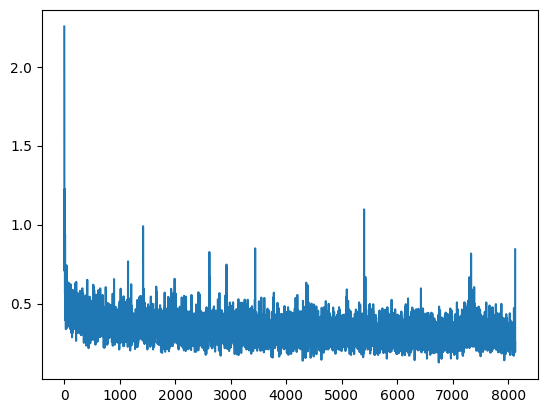

In [13]:
plt.plot(lossi);
# plt.show();

In [16]:
from collections import Counter

def show_class_distribution(dataset):
  labels = [label for _, label in dataset.samples]
  counts = Counter(labels)

  print("\nClass distribution:")
  for cls, count in counts.items():
    print(f"Class {cls}: {count}")

show_class_distribution(dataset)


Class distribution:
Class 0: 468356
Class 1: 268653
Class 2: 290420
Class 3: 4755
Class 4: 2296
Class 5: 5654


In [19]:
def compute_class_weights(dataset, num_classes):
  labels = [label for _, label in dataset.samples]
  counts = np.bincount(labels, minlength=num_classes)

  weights = 1.0 / (counts + 1e-6)
  weights = weights / weights.sum() * num_classes

  return torch.tensor(weights, dtype=torch.float).to(DEVICE)

class_weights = compute_class_weights(dataset, len(dataset.classes))


In [20]:
class_weights

tensor([0.0154, 0.0268, 0.0248, 1.5166, 3.1409, 1.2755], device='cuda:0')